# MCS Track Statistics by COF Type — Multi-Source Comparison

Diagnostic notebook comparing **MCS lifetime statistics** across six model/observation
datasets (OBS, SCREAM, ICON, UM, NICAM, CASESM2), stratified by the
**Co-occurring Feature (COF) type** of each MCS track.

---

## Input data

Input is a single snappy-compressed parquet file generated by
**`scripts/combine_mcs_cof_trackstats_multisource.py`**, which:

1. Loads PyFLEXTRKR MCS track-statistics netCDF files and COF 2-D overlap masks
   for all six sources.
2. Filters out tracks that are not extra-tropical (retains tracks with
   lifetime-median |meanlat| ≥ 20°).
3. Converts to a tidy per-time-step DataFrame and writes a single parquet file.

| Dataset  | Description |
|----------|-------------|
| OBS      | GPM/IMERG-based observations |
| SCREAM   | SCREAMv1-cess2 GSRM simulation |
| ICON     | ICON GSRM simulation |
| UM       | UM GSRM simulation |
| NICAM    | NICAM GSRM simulation |
| CASESM2  | CAM-SE CAM6 GSRM simulation |

**Parquet file:** `/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/mcs_cof_trackstats_allsources.parquet`  
~200 MB · ~1.48 M rows · 74 columns

---

## Key analysis steps

1. **Load & preprocess** — read parquet, convert epoch timestamps to datetime,
   derive `ccs_area_all`, `core_area_ratio`, and `heavy_rain_ratio`.
2. **COF overlap fractions** — for each track compute the fraction of time steps
   co-occurring with AR only (`frac_ar`), ETC only (`frac_etc`), and both
   AR + ETC (`frac_ar_etc`).
3. **COF-type classification** — assign each track to one of four mutually
   exclusive types based on the dominant overlap fraction:

   | COF type | Rule |
   |----------|------|
   | Isolated   | all fractions == 0 |
   | MCS+AR+ETC | `frac_ar_etc` ≥ both 2-way fractions (3-way prioritised on ties) |
   | MCS+AR     | `frac_ar` strictly largest |
   | MCS+ETC    | `frac_etc` strictly largest |

4. **Lifetime aggregation** — reduce the per-time-step DataFrame to one row
   per track (`df_lt`) using physically appropriate aggregations (max, min,
   sum, median, mean) for each variable.
5. **Ocean / land sub-populations** — subset `df_lt` into ocean MCS
   (`pf_landfrac_lt_max < 0.05`) and land MCS (`pf_landfrac_lt_mean > 0.80`).

---

## Analysis plots

| Figure | Description |
|--------|-------------|
| **Box plots — All MCS** | 3 × 3 panel box plots of nine MCS lifetime statistics (track duration, max CCS area, minimum 11-µm Tb, movement speed, max PF major-axis length, max PF aspect ratio, max PF rain rate, total rainfall, and heavy-rain fraction) grouped by COF type and coloured by dataset. |
| **Box plots — Ocean MCS** | Same 3 × 3 layout restricted to ocean MCS tracks (`pf_landfrac_lt_max < 0.05`). |
| **Box plots — Land MCS** | Same 3 × 3 layout restricted to land MCS tracks (`pf_landfrac_lt_mean > 0.80`). |

All figures are saved to:  
`/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/`


In [1]:
import time
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import colormaps as colormaps
import warnings
warnings.filterwarnings('ignore')

## Data

The combined MCS track statistics + COF 2D overlap data are stored in a single snappy-compressed parquet file generated by **`scripts/combine_mcs_cof_trackstats_multisource.py`**, which:

1. Loads MCS track stats + COF 2D netCDF files for all 6 sources (OBS, SCREAM, ICON, UM, NICAM, CASESM2)
2. Filters out tropical tracks (lifetime-median |meanlat| < 20°, retaining extra-tropical MCS only)
3. Converts to a tidy per-time-step DataFrame and saves as parquet

**Output:** `/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/mcs_cof_trackstats_allsources.parquet`
~200 MB · ~1.48 M rows · 74 columns · ~8 min to generate for all 6 sources

In [2]:
# Paths
cof_dir      = "/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/"
parquet_path = os.path.join(cof_dir, "mcs_cof_trackstats_allsources.parquet")
fig_dir      = "/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/"

# Color scheme for sources (keyed by display name matching the 'dataset' column)
source_colors = {
    'OBS':     'darkgray',
    'SCREAM':  'dodgerblue',
    'ICON':    'deeppink',
    'UM':      'lime',
    'NICAM':   'green',
    'CASESM2': 'darkorange',
}

# Load the combined parquet file
print(f"Loading: {parquet_path}")
t0 = time.time()
df_all_src = pd.read_parquet(parquet_path)
print(f"Loaded in {time.time() - t0:.1f} s  |  "
      f"{df_all_src.shape[0]:,} rows × {df_all_src.shape[1]} cols")
print(f"Sources: {sorted(df_all_src['dataset'].unique().tolist())}")

Loading: /pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/mcs_cof_trackstats_allsources.parquet
Loaded in 1.8 s  |  1,484,489 rows × 74 cols
Sources: ['CASESM2', 'ICON', 'NICAM', 'OBS', 'SCREAM', 'UM']


In [3]:
# Convert epoch-second columns to pandas datetime (UTC, then timezone-stripped)
# base_time    : datetime of each valid time step
# start_basetime : track initiation time
# end_basetime   : track termination time
for col in ['base_time', 'start_basetime', 'end_basetime']:
    if col in df_all_src.columns:
        df_all_src[f'{col}_dt'] = pd.to_datetime(
            df_all_src[col], unit='s', origin='unix', utc=True
        ).dt.tz_localize(None)   # drop UTC tz-awareness → naive datetime

print("Added datetime columns:")
for col in ['base_time_dt', 'start_basetime_dt', 'end_basetime_dt']:
    if col in df_all_src.columns:
        print(f"  {col}: {df_all_src[col].dtype}  "
              f"range [{df_all_src[col].min()} → {df_all_src[col].max()}]")

Added datetime columns:
  base_time_dt: datetime64[ns]  range [2019-08-01 00:00:00 → 2021-03-01 00:00:00]
  start_basetime_dt: datetime64[ns]  range [2019-08-01 00:00:00 → 2021-02-28 19:00:00]
  end_basetime_dt: datetime64[ns]  range [2019-08-01 04:00:00 → 2021-03-01 00:00:00]


In [4]:
# Derived variables
# ccs_area_all    : total CCS area including merged and split cloud systems
# core_area_ratio : convective core fraction of the total CCS area
# heavy_rain_ratio: fraction of total rainfall that is heavy rain
df_all_src['ccs_area_all']     = df_all_src['ccs_area'] + df_all_src['merge_ccs_area'] + df_all_src['split_ccs_area']
df_all_src['core_area_ratio']  = df_all_src['core_area'] / df_all_src['ccs_area']
df_all_src['heavy_rain_ratio'] = df_all_src['total_heavyrain'] / df_all_src['total_rain']

# Replace inf (division by zero when denominator == 0) with NaN
df_all_src.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Derived columns added:")
for col in ['ccs_area_all', 'core_area_ratio', 'heavy_rain_ratio']:
    print(f"  {col}: min={df_all_src[col].min():.4g}, "
          f"max={df_all_src[col].max():.4g}, "
          f"NaN={df_all_src[col].isna().sum():,}")

Derived columns added:
  ccs_area_all: min=900, max=1.281e+07, NaN=0
  core_area_ratio: min=0, max=1, NaN=0
  heavy_rain_ratio: min=0.0003197, max=1, NaN=362,666


In [5]:
# Diagnostic: check valid values in merge_ccs_area and split_ccs_area
for col in ['ccs_area', 'merge_ccs_area', 'split_ccs_area', 'ccs_area_all']:
    s = df_all_src[col]
    n_total  = len(s)
    n_nan    = s.isna().sum()
    n_valid  = n_total - n_nan
    n_nonzero = (s.fillna(0) != 0).sum()
    print(f"{col:25s}  total={n_total:>9,}  NaN={n_nan:>9,}  valid={n_valid:>9,}  nonzero={n_nonzero:>9,}"
          f"  min={s.min():.4g}  max={s.max():.4g}")

print()
print("Per-dataset summary of merge_ccs_area and split_ccs_area:")
for col in ['merge_ccs_area', 'split_ccs_area']:
    print(f"\n  {col}:")
    print(df_all_src.groupby('dataset')[col].agg(['count', 'min', 'max', 'mean',
          lambda x: x.isna().sum()]).rename(columns={'<lambda_0>': 'NaN_count'}).to_string())


ccs_area                   total=1,484,489  NaN=        0  valid=1,484,489  nonzero=1,484,489  min=900  max=8.902e+06
merge_ccs_area             total=1,484,489  NaN=        0  valid=1,484,489  nonzero=  713,619  min=0  max=4.546e+06
split_ccs_area             total=1,484,489  NaN=        0  valid=1,484,489  nonzero=  730,451  min=0  max=4.353e+06
ccs_area_all               total=1,484,489  NaN=        0  valid=1,484,489  nonzero=1,484,489  min=900  max=1.281e+07

Per-dataset summary of merge_ccs_area and split_ccs_area:

  merge_ccs_area:
          count  min        max          mean  NaN_count
dataset                                                 
CASESM2  102304  0.0  2559400.0  12287.218486          0
ICON     297221  0.0  4545600.0  48217.705007          0
NICAM    251787  0.0  2281700.0  18591.117095          0
OBS      266275  0.0  2061000.0  19264.408976          0
SCREAM   373813  0.0  2962300.0  26812.921969          0
UM       193089  0.0  1373800.0  12145.526156          

In [6]:
# Summary table: number of MCS tracks with any COF overlap per source
flag_vars = ['cof_flag_mcs_ar', 'cof_flag_mcs_etc', 'cof_flag_mcs_ar_etc', 'cof_flag_isolated']

rows = []
for src, grp in df_all_src.groupby('dataset'):
    n_tracks = grp['tracks'].nunique()
    row = {'source': src, 'n_tracks': n_tracks}
    for fv in flag_vars:
        if fv in grp.columns:
            # A track has overlap if any time step == 1
            row[fv] = int(grp.groupby('tracks')[fv].max().eq(1).sum())
        else:
            row[fv] = np.nan
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('source')
summary_df.columns = ['N tracks', 'MCS-AR', 'MCS-ETC', 'MCS-AR-ETC', 'Isolated']
print("Number of MCS tracks with any COF overlap:")
summary_df

Number of MCS tracks with any COF overlap:


,N tracks,MCS-AR,MCS-ETC,MCS-AR-ETC,Isolated
source,,,,,
CASESM2,4542,1379,555,537,3225
ICON,13410,3335,2150,1990,10983
NICAM,11744,2995,1885,1774,9397
OBS,13024,2933,2534,2320,10747
SCREAM,20710,3758,3288,2517,16556
UM,9347,2216,1124,1097,7235


In [7]:
# Inspect the combined DataFrame
print("Column list:")
print(df_all_src.columns.tolist())
print()
df_all_src.head(3)


Column list:
['tracks', 'relative_step', 'track_duration', 'start_status', 'end_status', 'start_basetime', 'end_basetime', 'start_split_cloudnumber', 'end_merge_cloudnumber', 'pbc_flag', 'base_time', 'meanlat', 'meanlon', 'area', 'cloudnumber', 'track_status', 'track_interruptions', 'core_area', 'cold_area', 'corecold_mintb', 'corecold_meantb', 'core_meantb', 'lat_mintb', 'lon_mintb', 'meanlon_smooth', 'meanlat_smooth', 'mcs_duration', 'mcs_status', 'ccs_area', 'merge_ccs_area', 'split_ccs_area', 'pf_npf', 'pf_lon', 'pf_lat', 'pf_area', 'pf_rainrate', 'pf_skewness', 'pf_majoraxis', 'pf_minoraxis', 'pf_aspectratio', 'pf_orientation', 'pf_perimeter', 'pf_eccentricity', 'pf_lon_centroid', 'pf_lat_centroid', 'pf_lon_weightedcentroid', 'pf_lat_weightedcentroid', 'pf_lon_maxrainrate', 'pf_lat_maxrainrate', 'pf_maxrainrate', 'pf_accumrain', 'pf_accumrainheavy', 'pf_landfrac', 'total_rain', 'total_heavyrain', 'rainrate_heavyrain', 'pf_lifetime', 'pf_mcsstatus', 'movement_distance', 'movement_s

,tracks,relative_step,track_duration,start_status,end_status,start_basetime,end_basetime,start_split_cloudnumber,end_merge_cloudnumber,pbc_flag,...,etc_tracknum_3way,relative_time_h,track_duration_h,dataset,base_time_dt,start_basetime_dt,end_basetime_dt,ccs_area_all,core_area_ratio,heavy_rain_ratio
0,0,0,31,15,21,1.564618e+09,1.564726e+09,-9999,1,0,...,0,0.0,31.0,OBS,2019-08-01 00:00:00,2019-08-01,2019-08-02 06:00:00,986600.0,0.027892,0.003865
1,0,1,31,15,21,1.564618e+09,1.564726e+09,-9999,1,0,...,0,1.0,31.0,OBS,2019-08-01 01:00:00,2019-08-01,2019-08-02 06:00:00,1090500.0,0.044941,0.008570
2,0,2,31,15,21,1.564618e+09,1.564726e+09,-9999,1,0,...,0,2.0,31.0,OBS,2019-08-01 02:00:00,2019-08-01,2019-08-02 06:00:00,964600.0,0.044644,0.007108


In [8]:
# One row per track (deduplicated) — useful for track-level statistics
df_tracks = df_all_src.drop_duplicates(subset=['dataset', 'tracks'])
print("Track duration (h) statistics per source:")
print(
    df_tracks.groupby('dataset')['track_duration_h']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95])
    .T
)


Track duration (h) statistics per source:
dataset      CASESM2          ICON         NICAM           OBS        SCREAM  \
count    4542.000000  13410.000000  11744.000000  13024.000000  20710.000000   
mean       22.523998     22.164131     21.439629     20.444948     18.049879   
std        25.261159     20.641516     18.089696     15.282646     15.770717   
min         5.000000      5.000000      5.000000      5.000000      5.000000   
25%        12.000000      9.000000     11.000000     11.000000      9.000000   
50%        17.000000     15.000000     16.000000     16.000000     13.000000   
75%        25.000000     27.000000     26.000000     25.000000     21.000000   
90%        39.000000     47.000000     41.000000     38.000000     34.000000   
95%        52.000000     64.000000     55.000000     49.000000     46.000000   
max       375.000000    227.000000    387.000000    230.000000    613.000000   

dataset           UM  
count    9347.000000  
mean       20.657858  
std     

## COF-based MCS track classification

For each track, compute the **fraction of valid time steps** where each COF flag == 1:

| Fraction | COF flag column | Meaning |
|---|---|---|
| `frac_ar` | `cof_flag_mcs_ar` | MCS co-occurs with AR only (2-way) |
| `frac_etc` | `cof_flag_mcs_etc` | MCS co-occurs with ETC only (2-way) |
| `frac_ar_etc` | `cof_flag_mcs_ar_etc` | MCS co-occurs with both AR & ETC (3-way) |

Tracks are then assigned to one of four **COF types** based on the dominant fraction:

1. **Isolated** — all three fractions are 0 (track never overlaps any AR or ETC)
2. **MCS+AR+ETC** — `frac_ar_etc` ≥ both 2-way fractions (3-way prioritised on ties)
3. **MCS+AR** — `frac_ar` is strictly largest
4. **MCS+ETC** — `frac_etc` is strictly largest

In [9]:
# -----------------------------------------------------------------------
# Step 1: compute per-track COF fractions
# cof_flag == 1 means the step overlaps; 0 = no overlap; -1/fill = invalid
# Fraction = (steps with flag==1) / track_duration
# -----------------------------------------------------------------------
def compute_cof_fractions(df):
    """Return a per-track DataFrame with COF overlap fractions."""
    grp = df.groupby(['dataset', 'tracks'], sort=False)
    duration = grp['track_duration'].first()   # same for all steps of a track
    frac = pd.DataFrame({
        'track_duration':  duration,
        'frac_ar':         grp['cof_flag_mcs_ar'].apply(lambda x: (x == 1).sum()) / duration,
        'frac_etc':        grp['cof_flag_mcs_etc'].apply(lambda x: (x == 1).sum()) / duration,
        'frac_ar_etc':     grp['cof_flag_mcs_ar_etc'].apply(lambda x: (x == 1).sum()) / duration,
    })
    return frac.reset_index()

df_cof_frac = compute_cof_fractions(df_all_src)

# -----------------------------------------------------------------------
# Step 2: classify each track into one of 4 COF types
#
# Priority rules (applied in order):
#   1. Isolated    — all three fractions == 0
#   2. MCS+AR+ETC  — frac_ar_etc >= frac_ar  AND  frac_ar_etc >= frac_etc
#                    (3-way wins on ties with either 2-way type)
#   3. MCS+AR      — frac_ar  is strictly the largest
#   4. MCS+ETC     — frac_etc is strictly the largest
# -----------------------------------------------------------------------
def classify_cof_type(row):
    fa, fe, fae = row['frac_ar'], row['frac_etc'], row['frac_ar_etc']
    if fa == 0 and fe == 0 and fae == 0:
        return 'Isolated'
    if fae >= fa and fae >= fe:
        return 'MCS+AR+ETC'
    if fa > fe:                            # fa > fae already; fa > fe → AR wins
        return 'MCS+AR'
    return 'MCS+ETC'

df_cof_frac['cof_type'] = df_cof_frac.apply(classify_cof_type, axis=1)

# -----------------------------------------------------------------------
# Step 3: summary table — counts and % per source and type
# -----------------------------------------------------------------------
type_order = ['Isolated', 'MCS+AR+ETC', 'MCS+AR', 'MCS+ETC']

counts = (
    df_cof_frac.groupby(['dataset', 'cof_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=type_order, fill_value=0)
)
counts['Total'] = counts.sum(axis=1)

pct = counts[type_order].div(counts['Total'], axis=0).mul(100).round(1)
pct.columns = [f'{c} (%)' for c in type_order]

summary_types = pd.concat([counts, pct], axis=1)
print("MCS track counts and percentage by COF type:")
print(summary_types.to_string())

# -----------------------------------------------------------------------
# Step 4: completeness check — does every track get exactly one type?
# -----------------------------------------------------------------------
n_classified  = len(df_cof_frac)
n_total_tracks = df_all_src.groupby(['dataset', 'tracks']).ngroups
unclassified  = df_cof_frac['cof_type'].isna().sum()

print(f"\nTracks classified : {n_classified:,}")
print(f"Tracks in df      : {n_total_tracks:,}")
print(f"Unclassified      : {unclassified}")
print(f"✓ All tracks accounted for: {n_classified == n_total_tracks and unclassified == 0}")

MCS track counts and percentage by COF type:
         Isolated  MCS+AR+ETC  MCS+AR  MCS+ETC  Total  Isolated (%)  MCS+AR+ETC (%)  MCS+AR (%)  MCS+ETC (%)
dataset                                                                                                     
CASESM2      2516         377    1184      465   4542          55.4             8.3        26.1         10.2
ICON         7655        1366    2740     1649  13410          57.1            10.2        20.4         12.3
NICAM        6630        1247    2407     1460  11744          56.5            10.6        20.5         12.4
OBS          7019        1703    2286     2016  13024          53.9            13.1        17.6         15.5
SCREAM      13060        1835    3027     2788  20710          63.1             8.9        14.6         13.5
UM           5766         776    1862      943   9347          61.7             8.3        19.9         10.1

Tracks classified : 72,777
Tracks in df      : 72,777
Unclassified      : 0
✓ All 

In [10]:
# Per-track lifetime statistics
# Each variable is aggregated with the operation most physically meaningful for it.
# pf_landfrac appears in both max and median → two output columns.
max_vars    = ['core_area', 'cold_area', 'ccs_area', 'ccs_area_all',
               'pf_area', 'pf_majoraxis', 'pf_aspectratio',
               'pf_maxrainrate', 'pf_rainrate', 'pf_landfrac', 'rainrate_heavyrain']
min_vars    = ['corecold_mintb', 'core_meantb', 'meanlat']
sum_vars    = ['total_rain', 'total_heavyrain']
median_vars = ['movement_speed', ]
mean_vars = ['core_area_ratio', 'heavy_rain_ratio', 'pf_landfrac']

df_lt = (
    df_all_src
    .groupby(['dataset', 'tracks'], sort=False)
    .agg(
        **{f'{c}_lt_max':    (c, 'max')    for c in max_vars},
        **{f'{c}_lt_min':    (c, 'min')    for c in min_vars},
        **{f'{c}_lt_sum':    (c, 'sum')    for c in sum_vars},
        **{f'{c}_lt_median': (c, 'median') for c in median_vars},
        **{f'{c}_lt_mean':   (c, 'mean')   for c in mean_vars},
    )
    .reset_index()
)

# Merge in track-level metadata (duration, COF type)
df_lt = df_lt.merge(
    df_all_src[['dataset', 'tracks', 'track_duration_h']].drop_duplicates(),
    on=['dataset', 'tracks'], how='left'
)
df_lt = df_lt.merge(
    df_cof_frac[['dataset', 'tracks', 'cof_type', 'frac_ar', 'frac_etc', 'frac_ar_etc']],
    on=['dataset', 'tracks'], how='left'
)

print(f"df_lt shape: {df_lt.shape}")
print(f"Columns: {df_lt.columns.tolist()}")
df_lt.head(3)

df_lt shape: (72777, 27)
Columns: ['dataset', 'tracks', 'core_area_lt_max', 'cold_area_lt_max', 'ccs_area_lt_max', 'ccs_area_all_lt_max', 'pf_area_lt_max', 'pf_majoraxis_lt_max', 'pf_aspectratio_lt_max', 'pf_maxrainrate_lt_max', 'pf_rainrate_lt_max', 'pf_landfrac_lt_max', 'rainrate_heavyrain_lt_max', 'corecold_mintb_lt_min', 'core_meantb_lt_min', 'meanlat_lt_min', 'total_rain_lt_sum', 'total_heavyrain_lt_sum', 'movement_speed_lt_median', 'core_area_ratio_lt_mean', 'heavy_rain_ratio_lt_mean', 'pf_landfrac_lt_mean', 'track_duration_h', 'cof_type', 'frac_ar', 'frac_etc', 'frac_ar_etc']


,dataset,tracks,core_area_lt_max,cold_area_lt_max,ccs_area_lt_max,ccs_area_all_lt_max,pf_area_lt_max,pf_majoraxis_lt_max,pf_aspectratio_lt_max,pf_maxrainrate_lt_max,...,total_heavyrain_lt_sum,movement_speed_lt_median,core_area_ratio_lt_mean,heavy_rain_ratio_lt_mean,pf_landfrac_lt_mean,track_duration_h,cof_type,frac_ar,frac_etc,frac_ar_etc
0,OBS,0,252700.0,1228000.0,1403300.0,1563500.0,340300.0,2168.116211,6.864587,19.115000,...,12692.339844,21.695139,0.135900,0.048364,0.0,31.0,MCS+AR+ETC,0.0,0.193548,0.580645
1,OBS,1,119500.0,565000.0,608300.0,900900.0,118300.0,1171.999756,7.326236,17.099998,...,7402.434570,9.399762,0.151790,0.074438,0.0,15.0,Isolated,0.0,0.000000,0.000000
2,OBS,2,51200.0,411300.0,428300.0,433100.0,227200.0,1333.081543,4.759075,32.519997,...,16396.664062,12.422600,0.057754,0.077479,0.0,31.0,MCS+AR,1.0,0.000000,0.000000


## MCS Track-Type Box Plots

Multi-panel box plots of lifetime statistics from `df_lt`, grouped by COF type on the x-axis with one box per dataset per type.

In [11]:
def plot_boxplots_by_mcs_type(
    df,
    variables,
    var_labels,
    figsize=(18, 10),
    title=None,
    title_y=0.98,
    source_colors=None,
    mcs_type_order=None,
    dataset_order=None,
    showfliers=False,
    whis=(5, 95),
    box_width=0.8,
    xtick_rotation=30,
    notch=False,
    panel_titles=None,
    panel_ylabels=None,
    yscale=None,
    fontsize=12,
    legend_ncol=None,
    legend_y=1.0,
    hspace=0.35,
    wspace=0.3,
    figname=None,
):
    """
    Multi-panel box-whisker plots of MCS lifetime statistics by COF type.

    Parameters
    ----------
    df : pd.DataFrame
        Per-track DataFrame (e.g. df_lt) with columns 'cof_type' and 'dataset'.
    variables : list of list of str
        2-D list of column names, e.g. [[var1, var2, var3], [var4, var5, var6]].
        Rows → subplot rows, columns → subplot columns.
    var_labels : dict
        {column_name: y-axis label string}
    figsize : tuple
    title : str or None
        Overall figure suptitle.  None = no suptitle.
    title_y : float
        Vertical position of the suptitle in figure coordinates (0–1).
        Raise above 1.0 to sit above the legend.
    source_colors : dict
        {dataset_display_name: color}.
    mcs_type_order : list of str
        Order of COF types on the x-axis.
    dataset_order : list of str
        Hue order (dataset display names).
    showfliers : bool
    whis : tuple
        (lower_pct, upper_pct) for whiskers.
    box_width : float
    xtick_rotation : int
    notch : bool
    panel_titles : list of list of str or None
    panel_ylabels : list of list of str or None
    yscale : list of list of str or None
        Same shape as variables.  Each entry is a matplotlib scale string
        ('linear', 'log', 'symlog', etc.).  None = all 'linear'.
    fontsize : int or float
        Base font size.  Scales:
          tick labels / axis labels: fontsize
          panel titles: fontsize + 1
          legend: fontsize
          suptitle: fontsize * 1.2
    legend_ncol : int or None
        Number of columns in the legend.  None = one column per dataset.
    legend_y : float
        **Primary control for legend vertical position** in figure coordinates.
        1.0 = flush with the top of the axes area; lower values (e.g. 0.97)
        tuck the legend closer to the top row of panels.  Values > 1.0 push
        it further above.  Adjust this first when the gap looks too large.
    hspace, wspace : float
    figname : str or None
        If not None, save the figure to this path.

    Returns
    -------
    matplotlib.figure.Figure
    """
    if source_colors is None:
        source_colors = {
            'OBS':     'darkgray',
            'SCREAM':  'dodgerblue',
            'ICON':    'deeppink',
            'UM':      'lime',
            'NICAM':   'green',
            'CASESM2': 'darkorange',
        }

    if mcs_type_order is None:
        mcs_type_order = ['Isolated', 'MCS+AR', 'MCS+ETC', 'MCS+AR+ETC']

    if dataset_order is None:
        dataset_order = ['OBS', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2']
    dataset_order = [d for d in dataset_order if d in df['dataset'].unique()]

    # Per-dataset sample counts (number of tracks)
    dataset_counts = df.groupby('dataset').size().to_dict()

    if legend_ncol is None:
        legend_ncol = len(dataset_order)

    nrows = len(variables)
    ncols = max(len(row) for row in variables)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             gridspec_kw=dict(hspace=hspace, wspace=wspace),
                             squeeze=False)

    meanpointprops = dict(marker='o', markeredgecolor='black', markeredgewidth=1,
                          markerfacecolor='white', markersize=6, zorder=3)
    medianprops = dict(color='k', linewidth=2, zorder=3)

    legend_ax = None  # will hold the axis used to harvest legend handles

    for i, var_row in enumerate(variables):
        for j in range(ncols):
            ax = axes[i, j]

            if j >= len(var_row):
                ax.set_visible(False)
                continue

            var = var_row[j]

            if var not in df.columns:
                ax.text(0.5, 0.5, f'"{var}"\nnot found',
                        ha='center', va='center', fontsize=fontsize, color='red',
                        transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            plot_df = df.dropna(subset=[var])

            sns.boxplot(
                data=plot_df,
                x='cof_type',
                y=var,
                hue='dataset',
                order=mcs_type_order,
                hue_order=dataset_order,
                palette=source_colors,
                showfliers=showfliers,
                whis=list(whis),
                width=box_width,
                showmeans=True,
                meanprops=meanpointprops,
                medianprops=medianprops,
                notch=notch,
                ax=ax,
            )

            # Keep one axis handle for harvesting legend artists
            if legend_ax is None:
                legend_ax = ax

            # Y-axis scale
            scale = 'linear'
            if yscale is not None and i < len(yscale) and j < len(yscale[i]):
                scale = yscale[i][j]
            ax.set_yscale(scale)

            # Y-axis label
            if panel_ylabels is not None and i < len(panel_ylabels) and j < len(panel_ylabels[i]):
                ylabel = panel_ylabels[i][j]
            else:
                ylabel = var_labels.get(var, var)
            ax.set_ylabel(ylabel, fontsize=fontsize, fontweight='bold')
            ax.set_xlabel('')

            # Panel title
            if panel_titles is not None and i < len(panel_titles) and j < len(panel_titles[i]):
                ax.set_title(panel_titles[i][j], fontsize=fontsize + 1,
                             fontweight='bold', loc='left')

            ax.grid(True, alpha=0.8, ls=':', axis='y')
            ax.tick_params(axis='both', labelsize=fontsize)
            ax.tick_params(axis='x', rotation=xtick_rotation)
            for lbl in ax.get_xticklabels():
                lbl.set_horizontalalignment('right')

            # Remove per-axis legend — replaced by figure-level legend below
            leg = ax.get_legend()
            if leg:
                leg.remove()

    # -----------------------------------------------------------------------
    # Figure-level legend above the top row.
    # legend_y is the primary knob: lower it (e.g. 0.97) to close the gap
    # between the legend and the top panels.
    # -----------------------------------------------------------------------
    if legend_ax is not None:
        handles, raw_labels = legend_ax.get_legend_handles_labels()
        new_labels = [
            f"{lbl} ({dataset_counts.get(lbl, 0):,})" for lbl in raw_labels
        ]
        fig.legend(
            handles, new_labels,
            loc='upper center',
            bbox_to_anchor=(0.5, legend_y),
            ncol=legend_ncol,
            fontsize=fontsize,
            title='',
            frameon=True,
        )

    if title is not None:
        fig.suptitle(title, fontsize=fontsize * 1.5, fontweight='bold', y=title_y)

    if figname is not None:
        fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved: {figname}")

    return fig


In [12]:
df_lt.keys()

Index(['dataset', 'tracks', 'core_area_lt_max', 'cold_area_lt_max',
       'ccs_area_lt_max', 'ccs_area_all_lt_max', 'pf_area_lt_max',
       'pf_majoraxis_lt_max', 'pf_aspectratio_lt_max', 'pf_maxrainrate_lt_max',
       'pf_rainrate_lt_max', 'pf_landfrac_lt_max', 'rainrate_heavyrain_lt_max',
       'corecold_mintb_lt_min', 'core_meantb_lt_min', 'meanlat_lt_min',
       'total_rain_lt_sum', 'total_heavyrain_lt_sum',
       'movement_speed_lt_median', 'core_area_ratio_lt_mean',
       'heavy_rain_ratio_lt_mean', 'pf_landfrac_lt_mean', 'track_duration_h',
       'cof_type', 'frac_ar', 'frac_etc', 'frac_ar_etc'],
      dtype='object')

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/Boxplot_MCS_by4COFtypes_3x3.pdf


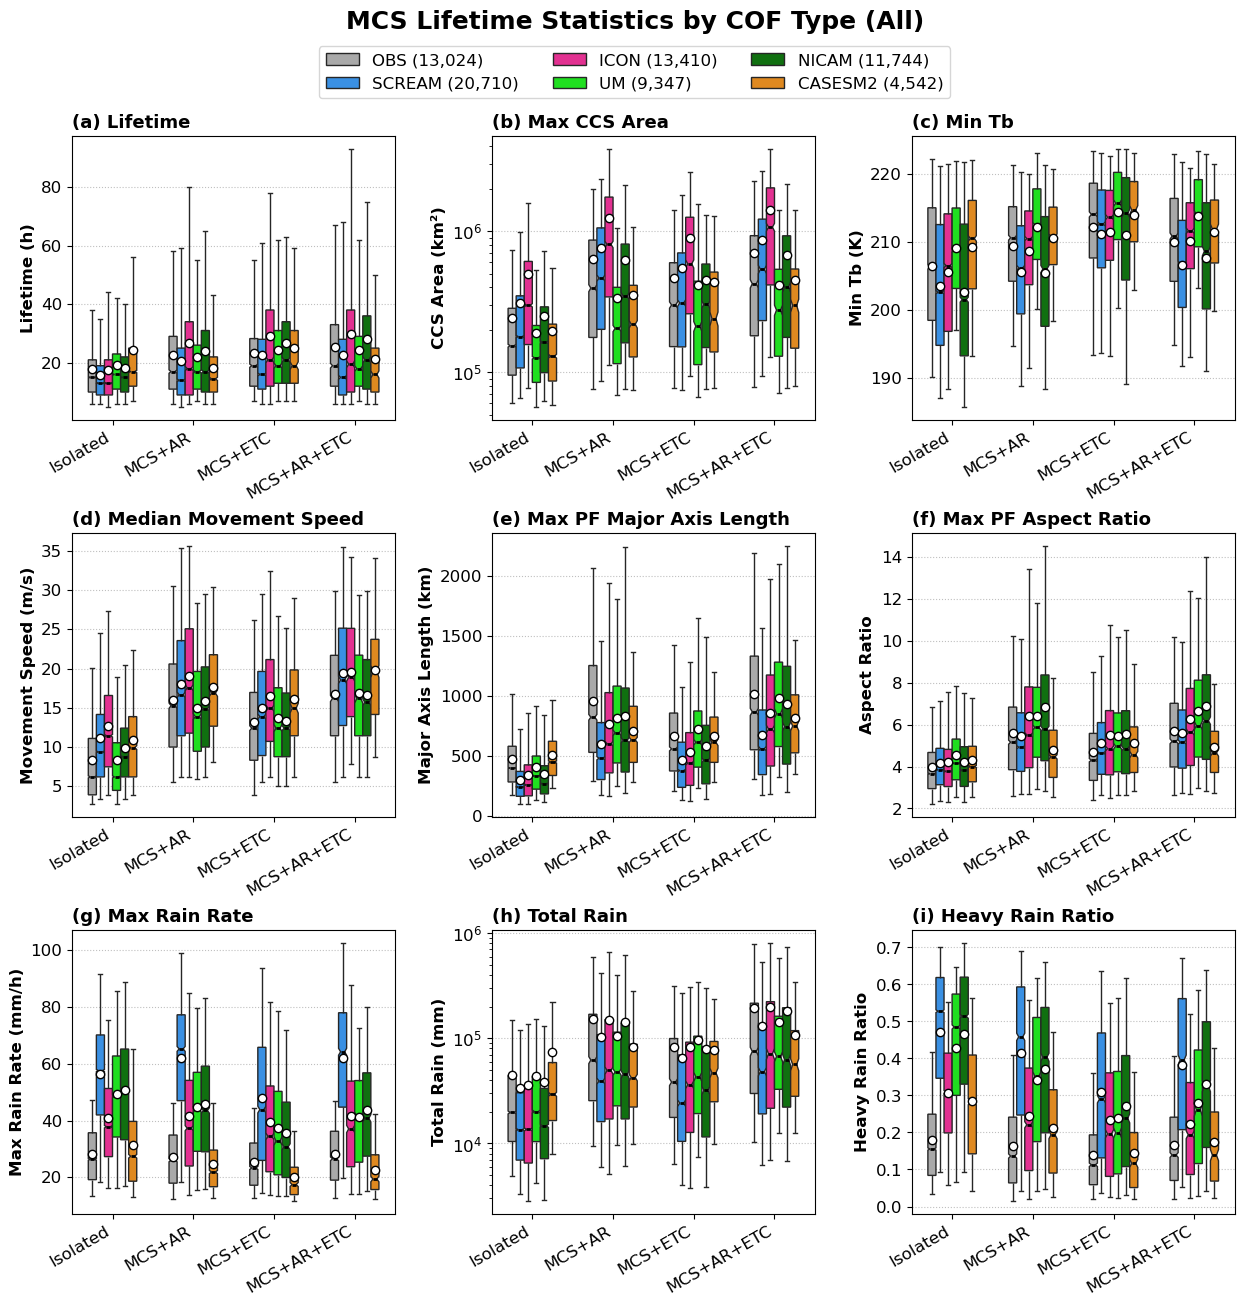

In [13]:
# Variable layout: 3 rows × 3 columns
lt_variables = [
    ['track_duration_h',  'ccs_area_all_lt_max',   'corecold_mintb_lt_min', ],
    ['movement_speed_lt_median',    'pf_majoraxis_lt_max',   'pf_aspectratio_lt_max', ],
    ['pf_maxrainrate_lt_max', 'total_rain_lt_sum',  'heavy_rain_ratio_lt_mean'],
]

panel_titles = [
    ['(a) Lifetime',      '(b) Max CCS Area',      '(c) Min Tb'],
    ['(d) Median Movement Speed',   '(e) Max PF Major Axis Length', '(f) Max PF Aspect Ratio'],
    ['(g) Max Rain Rate', '(h) Total Rain',        '(i) Heavy Rain Ratio'],
]

lt_var_labels = {
    'track_duration_h':         'Lifetime (h)',
    'ccs_area_all_lt_max':      'CCS Area (km²)',
    'corecold_mintb_lt_min':    'Min Tb (K)',
    'pf_area_lt_max':           'PF Area (km²)',
    'pf_rainrate_lt_max':       'Mean Rain Rate (mm/h)',
    'pf_majoraxis_lt_max':      'Major Axis Length (km)',
    'heavy_rain_ratio_lt_mean': 'Heavy Rain Ratio',
    'pf_aspectratio_lt_max':    'Aspect Ratio',
    'pf_maxrainrate_lt_max':    'Max Rain Rate (mm/h)',
    'total_rain_lt_sum':        'Total Rain (mm)',
    'movement_speed_lt_median': 'Movement Speed (m/s)',
}

# yscale: set log scale for area and rain variables
lt_yscale = [
    ['linear', 'log',    'linear'],
    ['linear', 'linear', 'linear'],
    ['linear', 'log',    'linear'],
]

figname = f"{fig_dir}Boxplot_MCS_by4COFtypes_3x3.pdf"

fig = plot_boxplots_by_mcs_type(
    df_lt,
    lt_variables,
    lt_var_labels,
    figsize=(15, 14),
    title="MCS Lifetime Statistics by COF Type (All)",
    title_y=0.97,
    source_colors=source_colors,
    dataset_order=['OBS', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2'],
    box_width=0.6,
    xtick_rotation=30,
    notch=True,
    panel_titles=panel_titles,
    yscale=lt_yscale,
    fontsize=12,
    legend_ncol=3,
    legend_y=0.95,   # lower this (e.g. 0.99) to close gap to top panels
    hspace=0.4, wspace=0.3,
    figname=figname,
)
plt.show()


## Ocean vs. Land MCS Sub-populations

Split `df_lt` into **ocean** and **land** subsets based on the lifetime land-fraction:

| Subset | Criterion | Rationale |
|--------|-----------|-----------|
| Ocean | `pf_landfrac_lt_max < ocean_thresh` (default 0.05) | Track never had >5% of its PF over land |
| Land  | `pf_landfrac_lt_mean > land_thresh` (default 0.80) | Track spent >80% of its lifetime predominantly over land |

Adjust `ocean_thresh` and `land_thresh` in the cell below to change the definitions.


In [14]:
# ── Thresholds (adjust here) ──────────────────────────────────────────────────
ocean_thresh = 0.05   # pf_landfrac_lt_max < ocean_thresh  →  ocean MCS
land_thresh  = 0.80   # pf_landfrac_lt_mean > land_thresh  →  land  MCS

# ── Subsets ───────────────────────────────────────────────────────────────────
df_ocean = df_lt[df_lt['pf_landfrac_lt_max']  <  ocean_thresh].copy()
df_land  = df_lt[df_lt['pf_landfrac_lt_mean'] >  land_thresh ].copy()

print(f"ocean_thresh = {ocean_thresh}  →  {len(df_ocean):,} tracks "
      f"({100*len(df_ocean)/len(df_lt):.1f}% of total)")
print(f"land_thresh  = {land_thresh}  →  {len(df_land):,} tracks "
      f"({100*len(df_land)/len(df_lt):.1f}% of total)")

print("\nOcean tracks per dataset:")
print(df_ocean.groupby('dataset').size().to_frame('n_tracks').T.to_string())
print("\nLand tracks per dataset:")
print(df_land.groupby('dataset').size().to_frame('n_tracks').T.to_string())


ocean_thresh = 0.05  →  33,448 tracks (46.0% of total)
land_thresh  = 0.8  →  23,910 tracks (32.9% of total)

Ocean tracks per dataset:
dataset   CASESM2  ICON  NICAM   OBS  SCREAM    UM
n_tracks     2866  5023   5487  5751    9020  5301

Land tracks per dataset:
dataset   CASESM2  ICON  NICAM   OBS  SCREAM    UM
n_tracks      750  5221   3883  4179    7768  2109


Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/Boxplot_MCS_by4COFtypes_3x3_ocean.pdf


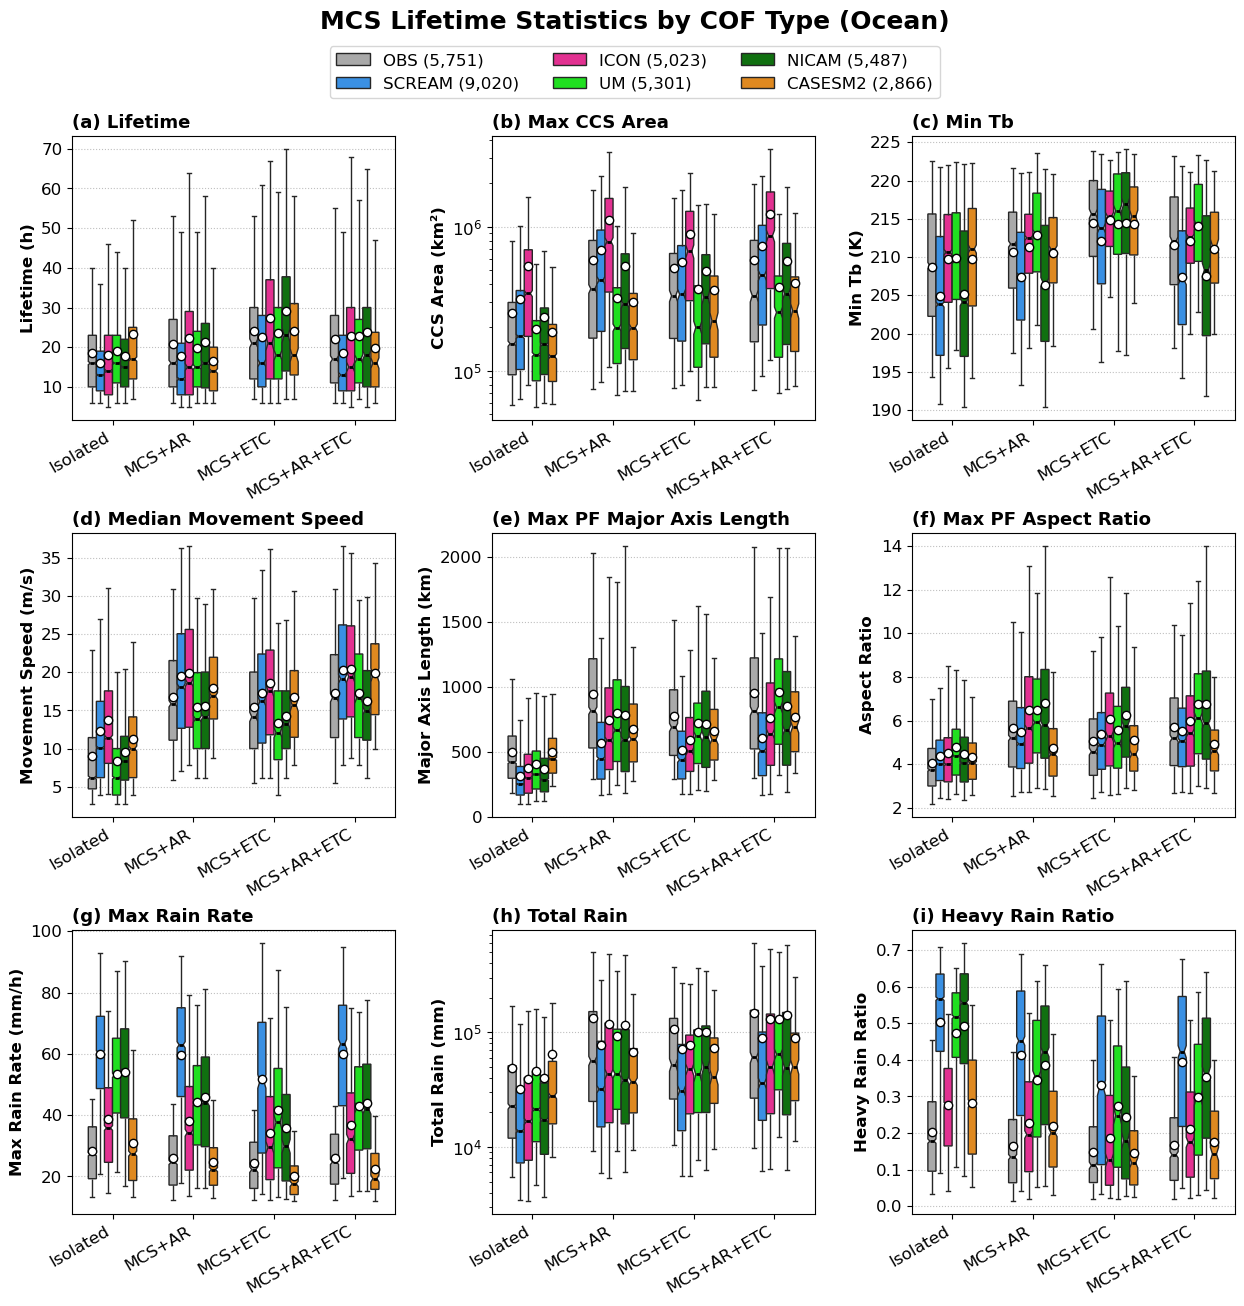

In [15]:
# ── Ocean MCS box plots ───────────────────────────────────────────────────────
figname_ocean = f"{fig_dir}Boxplot_MCS_by4COFtypes_3x3_ocean.pdf"

fig_ocean = plot_boxplots_by_mcs_type(
    df_ocean,
    lt_variables,
    lt_var_labels,
    figsize=(15, 14),
    title=f"MCS Lifetime Statistics by COF Type (Ocean)",
    title_y=0.97,
    source_colors=source_colors,
    dataset_order=['OBS', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2'],
    box_width=0.6,
    xtick_rotation=30,
    notch=True,
    panel_titles=panel_titles,
    yscale=lt_yscale,
    fontsize=12,
    legend_ncol=3,
    legend_y=0.95,
    hspace=0.4, wspace=0.3,
    figname=figname_ocean,
)
plt.show()


Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/Boxplot_MCS_by4COFtypes_3x3_land.pdf


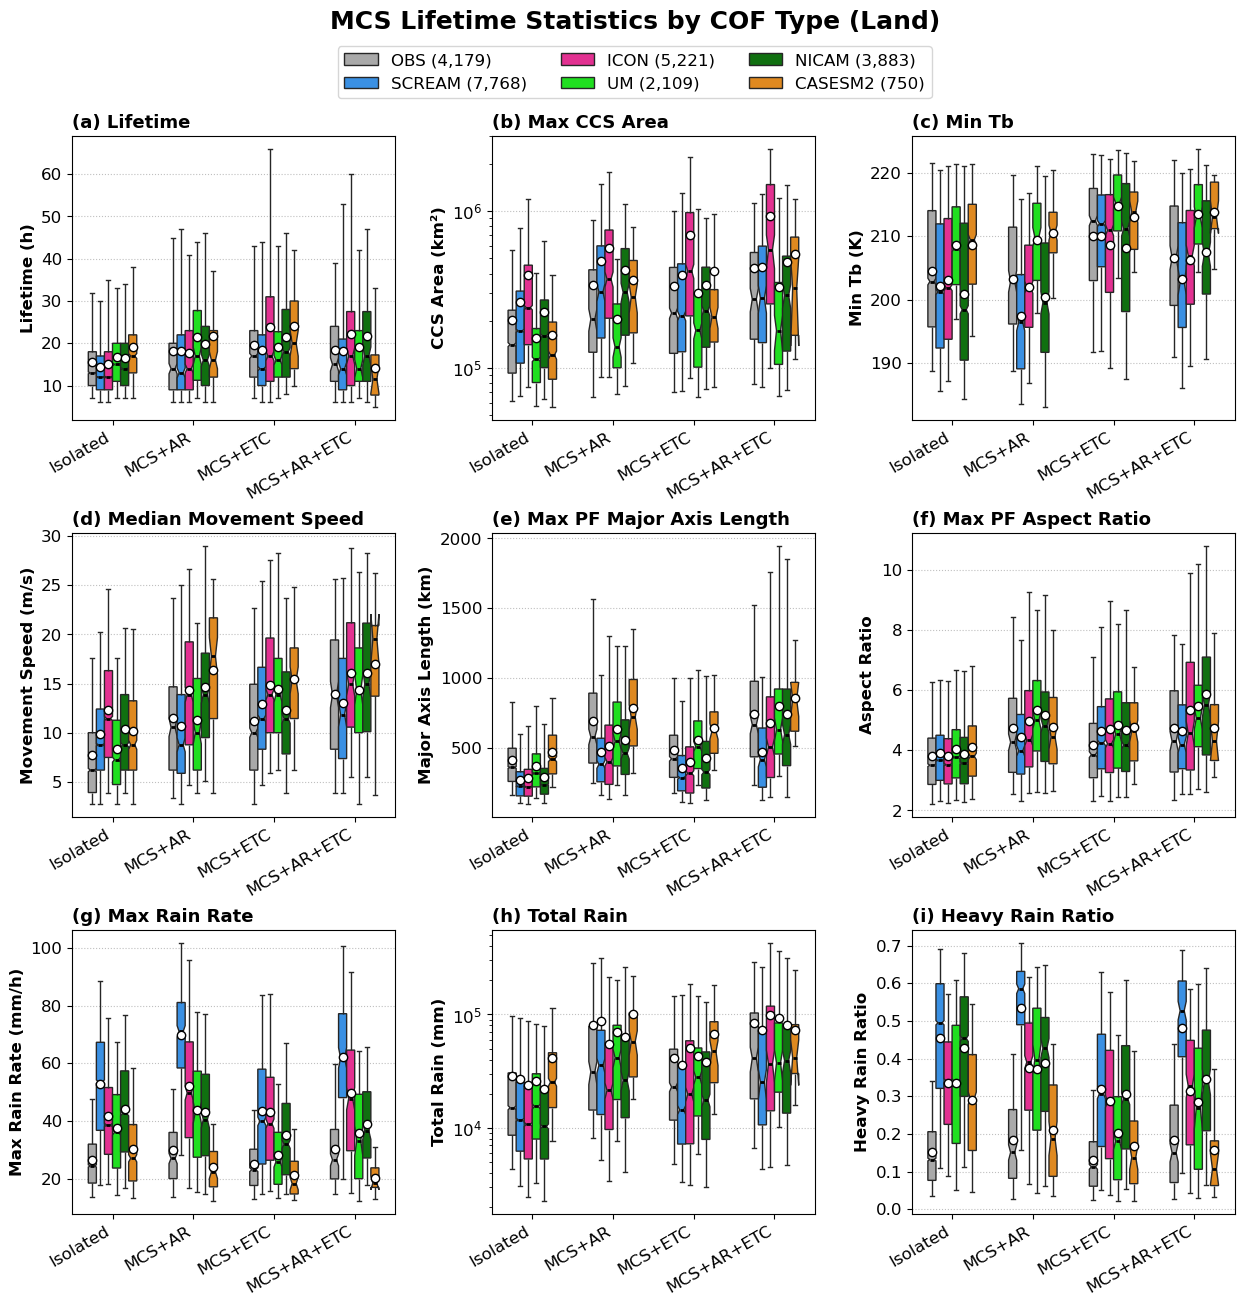

In [16]:
# ── Land MCS box plots ────────────────────────────────────────────────────────
figname_land = f"{fig_dir}Boxplot_MCS_by4COFtypes_3x3_land.pdf"

fig_land = plot_boxplots_by_mcs_type(
    df_land,
    lt_variables,
    lt_var_labels,
    figsize=(15, 14),
    title=f"MCS Lifetime Statistics by COF Type (Land)",
    title_y=0.97,
    source_colors=source_colors,
    dataset_order=['OBS', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2'],
    box_width=0.6,
    xtick_rotation=30,
    notch=True,
    panel_titles=panel_titles,
    yscale=lt_yscale,
    fontsize=12,
    legend_ncol=3,
    legend_y=0.95,
    hspace=0.4, wspace=0.3,
    figname=figname_land,
)
plt.show()
